In [1]:
import yt
import numpy as np
from yt.mods import *
from yt.frontends.boxlib.api import NyxDataset, AMReXDataset
from yt.data_objects.time_series import DatasetSeries
import matplotlib.pyplot as plt
from matplotlib import rc_context
from matplotlib.animation import FuncAnimation
from IPython import display

In [2]:
class AMReXDatasetSeries(DatasetSeries):
    _dataset_cls = AMReXDataset

In [3]:
path = "../Outputs/Subcycle/LowRes/plt0????"
dsLoad = AMReXDatasetSeries(path)

In [4]:
ds = []
for data in dsLoad:
    ds.append(data)

yt : [INFO     ] 2023-02-02 15:52:20,503 Parameters: current_time              = 0.0
yt : [INFO     ] 2023-02-02 15:52:20,504 Parameters: domain_dimensions         = [64 64 64]
yt : [INFO     ] 2023-02-02 15:52:20,506 Parameters: domain_left_edge          = [0. 0. 0.]
yt : [INFO     ] 2023-02-02 15:52:20,507 Parameters: domain_right_edge         = [30. 30. 30.]
yt : [INFO     ] 2023-02-02 15:52:20,559 Parameters: current_time              = 4.0
yt : [INFO     ] 2023-02-02 15:52:20,560 Parameters: domain_dimensions         = [64 64 64]
yt : [INFO     ] 2023-02-02 15:52:20,562 Parameters: domain_left_edge          = [0. 0. 0.]
yt : [INFO     ] 2023-02-02 15:52:20,562 Parameters: domain_right_edge         = [30. 30. 30.]
yt : [INFO     ] 2023-02-02 15:52:20,617 Parameters: current_time              = 8.0
yt : [INFO     ] 2023-02-02 15:52:20,618 Parameters: domain_dimensions         = [64 64 64]
yt : [INFO     ] 2023-02-02 15:52:20,619 Parameters: domain_left_edge          = [0. 0. 0.]
yt 

In [5]:
def _relE (field, dat):
    av = dat.ds.all_data().quantities.weighted_average_quantity("Edens", weight = ("index", "ones"))
    return dat["Edens"]/av
for data in ds:
    data.add_field(("boxlib","EdensRel"), function=_relE, sampling_type="local", units="dimensionless",force_override=True)

yt : [INFO     ] 2023-02-02 15:52:32,900 xlim = 0.000000 30.000000
yt : [INFO     ] 2023-02-02 15:52:32,901 ylim = 0.000000 30.000000
yt : [INFO     ] 2023-02-02 15:52:32,902 xlim = 0.000000 30.000000
yt : [INFO     ] 2023-02-02 15:52:32,903 ylim = 0.000000 30.000000
yt : [INFO     ] 2023-02-02 15:52:32,905 Making a fixed resolution buffer of (('boxlib', 'EdensRel')) 800 by 800



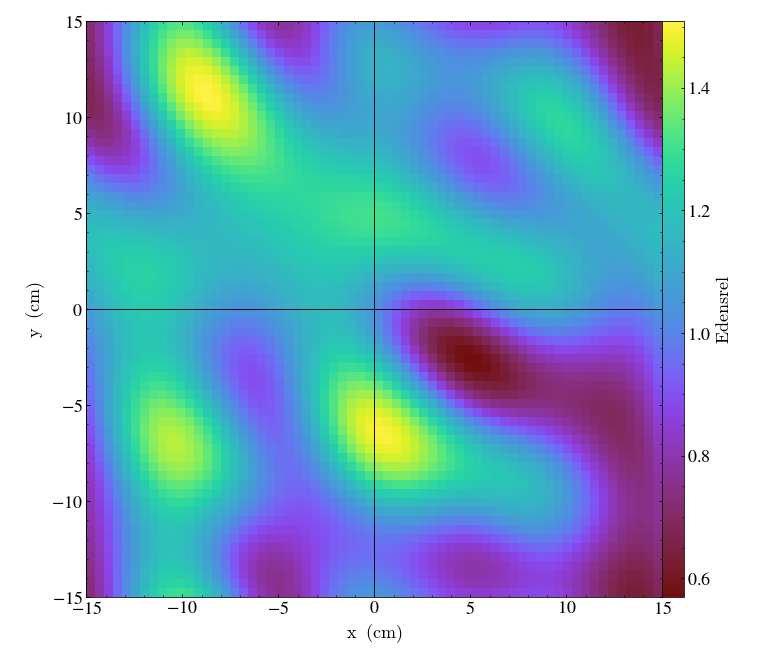

In [6]:
plot = yt.SlicePlot(ds[0], "z", "EdensRel")#, center = [0,0,0])
#plot.set_zlim(("boxlib", "KGfdens"), 1e-13, 2e1)
plot.set_log("EdensRel", False)
#plot.show()
plot.annotate_grids()

In [7]:
fig = plot.plots[("boxlib", "EdensRel")].figure

In [8]:
def animate(i):
    ts = ds[i]
    plot._switch_ds(ts)

In [9]:
animation = FuncAnimation(fig, animate, frames=len(ds))

In [10]:
# Override matplotlib's defaults to get a nicer looking font
with rc_context({"mathtext.fontset": "stix"}):
    #animation.save("animation.mp4")
    video = animation.to_html5_video()
    html = display.HTML(video)
    display.display(html)